# Import

## Import lib and dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
# Clone the entire repo.

!git clone https://github.com/RomainReina/semantic-search-engine.git

Cloning into 'semantic-search-engine'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 7 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 15.04 MiB | 13.20 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [ ]:
!unzip /content/semantic-search-engine/archive.zip -d /content/semantic-search-engine/archive

Archive:  /content/semantic-search-engine/archive.zip
  inflating: /content/semantic-search-engine/archive/flipkart_fashion_products_dataset.json  
  inflating: /content/semantic-search-engine/archive/output.xlsx  


In [ ]:
json_path = "/content/semantic-search-engine/archive/flipkart_fashion_products_dataset.json"
df=pd.read_json(json_path)
df.head()

,_id,actual_price,average_rating,brand,category,crawled_at,description,discount,images,out_of_stock,pid,product_details,seller,selling_price,sub_category,title,url
0,fa8e22d6-c0b6-5229-bb9e-ad52eda39a0a,"2,999",3.9,York,Clothing and Accessories,2021-02-10 20:11:51,Yorker trackpants made from 100% rich combed c...,69% off,[https://rukminim1.flixcart.com/image/128/128/...,False,TKPFCZ9EA7H5FYZH,"[{'Style Code': '1005COMBO2'}, {'Closure': 'El...",Shyam Enterprises,921,Bottomwear,Solid Men Multicolor Track Pants,https://www.flipkart.com/yorker-solid-men-mult...
1,893e6980-f2a0-531f-b056-34dd63fe912c,"1,499",3.9,York,Clothing and Accessories,2021-02-10 20:11:52,Yorker trackpants made from 100% rich combed c...,66% off,[https://rukminim1.flixcart.com/image/128/128/...,False,TKPFCZ9EJZV2UVRZ,"[{'Style Code': '1005BLUE'}, {'Closure': 'Draw...",Shyam Enterprises,499,Bottomwear,Solid Men Blue Track Pants,https://www.flipkart.com/yorker-solid-men-blue...
2,eb4c8eab-8206-59d0-bcd1-a724d96bf74f,"2,999",3.9,York,Clothing and Accessories,2021-02-10 20:11:52,Yorker trackpants made from 100% rich combed c...,68% off,[https://rukminim1.flixcart.com/image/128/128/...,False,TKPFCZ9EHFCY5Z4Y,"[{'Style Code': '1005COMBO4'}, {'Closure': 'El...",Shyam Enterprises,931,Bottomwear,Solid Men Multicolor Track Pants,https://www.flipkart.com/yorker-solid-men-mult...
3,3f3f97bb-5faf-57df-a9ff-1af24e2b1045,"2,999",3.9,York,Clothing and Accessories,2021-02-10 20:11:53,Yorker trackpants made from 100% rich combed c...,69% off,[https://rukminim1.flixcart.com/image/128/128/...,False,TKPFCZ9ESZZ7YWEF,"[{'Style Code': '1005COMBO3'}, {'Closure': 'El...",Shyam Enterprises,911,Bottomwear,Solid Men Multicolor Track Pants,https://www.flipkart.com/yorker-solid-men-mult...
4,750caa3d-6264-53ca-8ce1-94118a1d8951,"2,999",3.9,York,Clothing and Accessories,2021-02-10 20:11:53,Yorker trackpants made from 100% rich combed c...,68% off,[https://rukminim1.flixcart.com/image/128/128/...,False,TKPFCZ9EVXKBSUD7,"[{'Style Code': '1005COMBO1'}, {'Closure': 'Dr...",Shyam Enterprises,943,Bottomwear,"Solid Men Brown, Grey Track Pants",https://www.flipkart.com/yorker-solid-men-brow...


## Pre-analysis

In [ ]:
df['category'].value_counts()

,count
category,
Clothing and Accessories,28971
Footwear,987
"Bags, Wallets & Belts",41
Toys,1


In [ ]:
df['sub_category'].value_counts()

,count
sub_category,
Topwear,16575
Bottomwear,3862
Winter Wear,2753
Innerwear and Swimwear,1774
Clothing Accessories,1760
"Kurtas, Ethnic Sets and Bottoms",1248
Men's Footwear,987
Fabrics,535
"Blazers, Waistcoats and Suits",136


# Text Preprocessing

In [ ]:
def preprocess_text(text):
  """
  text: str
  return: str

  Preprocess text will do the following:
  - lower capitalisation
  - remove HTML
  - remove URLs
  - remove punctuation
  - remove extra spaces
  """
    text = str(text).lower() # # lower capitalisation
    text = re.sub(r'<.*?>', ' ', text)          # remove HTML
    text = re.sub(r'http\S+|www\S+', ' ', text) # remove URLs
    text = re.sub(r'[^\w\s]', ' ', text)        # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()    # remove extra spaces
    return text


In [ ]:
df_pp = df.copy()

# concat text columns and prepocess into new columns
text_columns = [
    "title",
    "description",
    "brand",
    "category",
    "sub_category"
]

# add new collumns from concatenation from the text columns
df_pp["full_text"] = df[text_columns].agg(" ".join, axis=1)

# add new collumns with preprocessing method
df_pp["clean_text"] = df_pp["full_text"].apply(preprocess_text)

df_pp.head()

,_id,actual_price,average_rating,brand,category,crawled_at,description,discount,images,out_of_stock,pid,product_details,seller,selling_price,sub_category,title,url,full_text,clean_text
0,fa8e22d6-c0b6-5229-bb9e-ad52eda39a0a,"2,999",3.9,York,Clothing and Accessories,2021-02-10 20:11:51,Yorker trackpants made from 100% rich combed c...,69% off,[https://rukminim1.flixcart.com/image/128/128/...,False,TKPFCZ9EA7H5FYZH,"[{'Style Code': '1005COMBO2'}, {'Closure': 'El...",Shyam Enterprises,921,Bottomwear,Solid Men Multicolor Track Pants,https://www.flipkart.com/yorker-solid-men-mult...,Solid Men Multicolor Track Pants Yorker trackp...,solid men multicolor track pants yorker trackp...
1,893e6980-f2a0-531f-b056-34dd63fe912c,"1,499",3.9,York,Clothing and Accessories,2021-02-10 20:11:52,Yorker trackpants made from 100% rich combed c...,66% off,[https://rukminim1.flixcart.com/image/128/128/...,False,TKPFCZ9EJZV2UVRZ,"[{'Style Code': '1005BLUE'}, {'Closure': 'Draw...",Shyam Enterprises,499,Bottomwear,Solid Men Blue Track Pants,https://www.flipkart.com/yorker-solid-men-blue...,Solid Men Blue Track Pants Yorker trackpants m...,solid men blue track pants yorker trackpants m...
2,eb4c8eab-8206-59d0-bcd1-a724d96bf74f,"2,999",3.9,York,Clothing and Accessories,2021-02-10 20:11:52,Yorker trackpants made from 100% rich combed c...,68% off,[https://rukminim1.flixcart.com/image/128/128/...,False,TKPFCZ9EHFCY5Z4Y,"[{'Style Code': '1005COMBO4'}, {'Closure': 'El...",Shyam Enterprises,931,Bottomwear,Solid Men Multicolor Track Pants,https://www.flipkart.com/yorker-solid-men-mult...,Solid Men Multicolor Track Pants Yorker trackp...,solid men multicolor track pants yorker trackp...
3,3f3f97bb-5faf-57df-a9ff-1af24e2b1045,"2,999",3.9,York,Clothing and Accessories,2021-02-10 20:11:53,Yorker trackpants made from 100% rich combed c...,69% off,[https://rukminim1.flixcart.com/image/128/128/...,False,TKPFCZ9ESZZ7YWEF,"[{'Style Code': '1005COMBO3'}, {'Closure': 'El...",Shyam Enterprises,911,Bottomwear,Solid Men Multicolor Track Pants,https://www.flipkart.com/yorker-solid-men-mult...,Solid Men Multicolor Track Pants Yorker trackp...,solid men multicolor track pants yorker trackp...
4,750caa3d-6264-53ca-8ce1-94118a1d8951,"2,999",3.9,York,Clothing and Accessories,2021-02-10 20:11:53,Yorker trackpants made from 100% rich combed c...,68% off,[https://rukminim1.flixcart.com/image/128/128/...,False,TKPFCZ9EVXKBSUD7,"[{'Style Code': '1005COMBO1'}, {'Closure': 'Dr...",Shyam Enterprises,943,Bottomwear,"Solid Men Brown, Grey Track Pants",https://www.flipkart.com/yorker-solid-men-brow...,"Solid Men Brown, Grey Track Pants Yorker track...",solid men brown grey track pants yorker trackp...


INPUT:

Solid Men Multicolor Track Pants Yorker trackpants made from 100% rich combed cotton giving it a rich look.Designed for Comfort,Skin friendly fabric,itch-free waistband & great for all year round use Proudly made in India York Clothing and Accessories Bottomwear

OUTPUT:

solid men multicolor track pants yorker trackpants made from 100 rich combed cotton giving it a rich look designed for comfort skin friendly fabric itch free waistband great for all year round use proudly made in india york clothing and accessories bottomwear

## removing duplicates

In [ ]:
print(str(df_pp.duplicated(subset="clean_text").sum()) + " duplicate")

df_pp = df_pp.drop_duplicates(subset="clean_text")
df_pp = df_pp.reset_index(drop=True)

print(str(df_pp.duplicated(subset="clean_text").sum()) + " duplicate")

16658 duplicate
0 duplicate


## checks low entree

In [ ]:
# checking low len and low word
for k in df_pp["clean_text"]:
  if len(k.split()) < 5:
    df_pp[k].drop(k, inplace=True)
  if len(k) < 40:
    df_pp[k].drop(k, inplace=True)

In [ ]:
print("Remaining rows: " + str(len(df_pp)) +" over " + str(len(df)))

Remaining rows: 13342 over 30000



# Convert Texts into Embeddings

## SBERT: SentenceTransformer Model

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
#model = SentenceTransformer("all-mpnet-base-v2")
model = SentenceTransformer("all-MiniLM-L6-v2")
texts = df_pp["clean_text"].astype(str).tolist()

embeddings = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/209 [00:00<?, ?it/s]

In [ ]:
print(embeddings.shape)

(13342, 384)


In [ ]:
# saving model
np.save("product_embeddings.npy", embeddings)
df_pp.to_csv("products_cleaned.csv", index=False)

## Test

In [ ]:
query = "black shirt for men"
query_embedding = model.encode([query], normalize_embeddings=True)

print(query_embedding.shape)

(1, 384)


the query is well executed into array vector

#Build a FAISS Index

FAISS est une bibliothèque open-source spécialisée dans la recherche des plus proches voisins dans des ensembles de vecteurs.

https://kaizzen.fr/2025/05/02/comment-faiss-revolutionne-t-il-la-recherche-documentaire/

In [ ]:
!pip install -q faiss-cpu

import faiss

In [ ]:
embeddings = np.load("product_embeddings.npy") # load our model

In [ ]:
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)  # cosine similarity
index.add(embeddings)

print("Number of products in index:", index.ntotal)

Number of products in index: 13342


# answer

## User Request

In [ ]:
query = "men black shirt"
query_embedding = model.encode([query], normalize_embeddings=True)
#print(query_embedding)

## Find close answer

In [ ]:
scores, indices = index.search(query_embedding, k=5) # k=5 means 5 products chose close to the reel target
print(scores)
print(indices)

[[0.7343024  0.70700204 0.7058158  0.7015108  0.7007172 ]]
[[ 4416 12595  6664  4400 12579]]


## print result

In [ ]:
results = df_pp.iloc[indices[0]].copy()
results["similarity_score"] = scores[0]

In [ ]:
print(results['title'])
print(results["brand"])
print(results["category"])
print(results["similarity_score"])

4416     Printed Men Round Neck Black T-Shirt
12595    Striped Men Round Neck Black T-Shirt
6664     Printed Men Round Neck Black T-Shirt
4400     Printed Men Round Neck Black T-Shirt
12579    Printed Men Round Neck Black T-Shirt
Name: title, dtype: object
4416     MASH UNLIMIT
12595        BLACK SN
6664       Marca Disa
4400     MASH UNLIMIT
12579              Pu
Name: brand, dtype: object
4416     Clothing and Accessories
12595    Clothing and Accessories
6664     Clothing and Accessories
4400     Clothing and Accessories
12579    Clothing and Accessories
Name: category, dtype: object
4416     0.734302
12595    0.707002
6664     0.705816
4400     0.701511
12579    0.700717
Name: similarity_score, dtype: float32


# graphique

In [ ]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_2d = reducer.fit_transform(embeddings)

df_plot = df_pp.copy()
df_plot["x"] = embeddings_2d[:,0]
df_plot["y"] = embeddings_2d[:,1]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
def show_result(text):
  query_embedding = model.encode([text], normalize_embeddings=True)
  query_2d = reducer.transform(query_embedding)
  scores, indices = index.search(query_embedding, k=5)

  sns.scatterplot(x="x", y="y", hue="category", data=df_plot, alpha=0.7)
  plt.scatter(query_2d[0,0], query_2d[0,1], color="red", s=200, marker="X", label="Query",)

  plt.show()

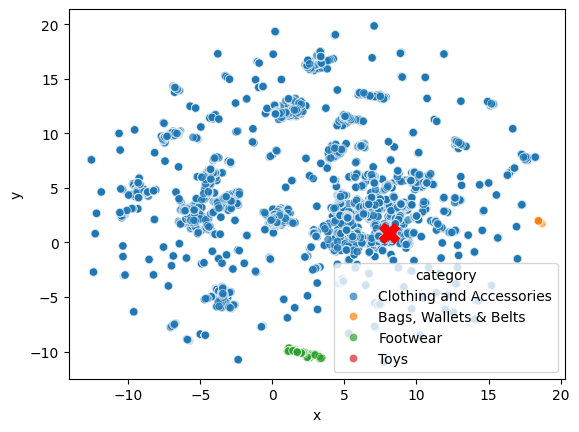

In [ ]:
show_result("men black shirt")

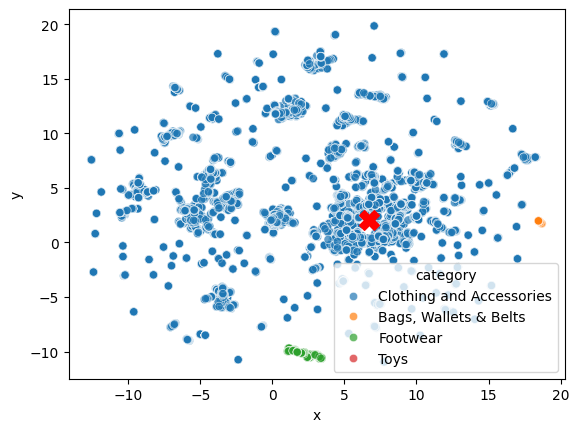

In [ ]:
show_result("women black shirt")

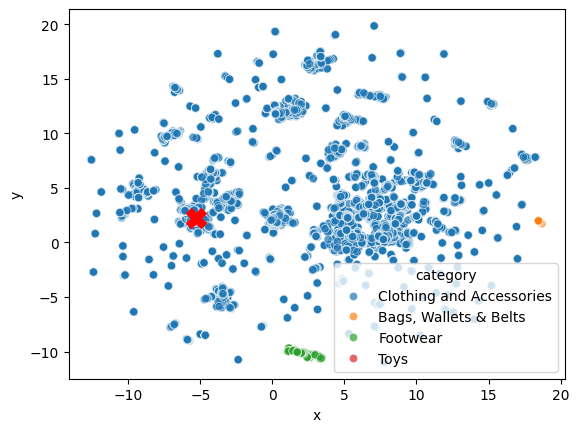

In [ ]:
show_result("black pant")

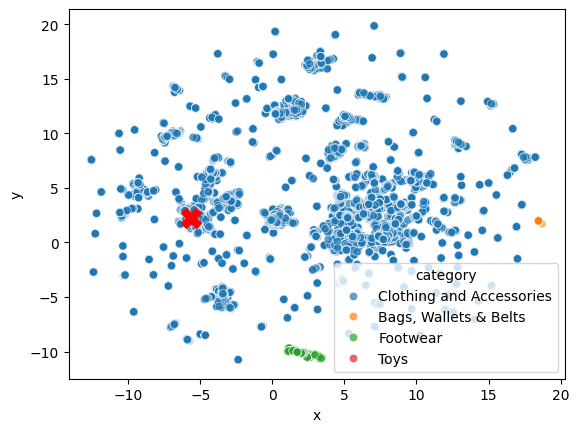

In [ ]:
show_result("blue pant")

In [ ]:
def show_result_subc(text):
  query_embedding = model.encode([text], normalize_embeddings=True)
  query_2d = reducer.transform(query_embedding)
  scores, indices = index.search(query_embedding, k=5)

  sns.scatterplot(x="x", y="y", hue="sub_category", data=df_plot, alpha=0.7)
  plt.scatter(query_2d[0,0], query_2d[0,1], color="red", s=200, marker="X", label="Query",)

  plt.show()

Conclusion:

Le dataset ne comport que des vetements, il faut essayer avec un dataset plus varier, avec plus de categorie